In [21]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


In [22]:
# 1. Load MNIST dataset
# --------------------------
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

# Normalize to [0,1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten 28x28 -> 784
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (60000, 784)
Test shape: (10000, 784)


In [23]:
# 2. Sampling layer
# --------------------------
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon


In [24]:
# 3. Encoder
# --------------------------
latent_dim = 2

encoder_inputs = layers.Input(shape=(784,))
x = layers.Dense(256, activation="relu")(encoder_inputs)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])

encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │    200,960 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        514 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        514 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_1          │ (None, 2)         │          0 │ z_mean[0][0],     │
│ (Sampling)          │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 201,988 (789.02 KB)

 Trainable params: 201,988 (789.02 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# 4. Decoder
# --------------------------
latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(256, activation="relu")(latent_inputs)
decoder_outputs = layers.Dense(784, activation="sigmoid")(x)

decoder = Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()


Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 202,256 (790.06 KB)

 Trainable params: 202,256 (790.06 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# 5. VAE model
# --------------------------
class VAE(Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

        self.val_total_loss_tracker = tf.keras.metrics.Mean(name="val_total_loss")
        self.val_reconstruction_loss_tracker = tf.keras.metrics.Mean(name="val_reconstruction_loss")
        self.val_kl_loss_tracker = tf.keras.metrics.Mean(name="val_kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
            self.val_total_loss_tracker,
            self.val_reconstruction_loss_tracker,
            self.val_kl_loss_tracker,
        ]

    def compute_losses(self, data):
        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z)

        # Manual binary crossentropy for stability
        reconstruction = tf.clip_by_value(reconstruction, 1e-7, 1 - 1e-7)
        reconstruction_loss = -tf.reduce_sum(
            data * tf.math.log(reconstruction) +
            (1 - data) * tf.math.log(1 - reconstruction),
            axis=1
        )
        reconstruction_loss = tf.reduce_mean(reconstruction_loss)

        kl_loss = -0.5 * tf.reduce_sum(
            1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
            axis=1
        )
        kl_loss = tf.reduce_mean(kl_loss)

        total_loss = reconstruction_loss + kl_loss
        return total_loss, reconstruction_loss, kl_loss

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            total_loss, reconstruction_loss, kl_loss = self.compute_losses(data)

        grads = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "total_loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def test_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        total_loss, reconstruction_loss, kl_loss = self.compute_losses(data)

        self.val_total_loss_tracker.update_state(total_loss)
        self.val_reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.val_kl_loss_tracker.update_state(kl_loss)

        return {
            "val_total_loss": self.val_total_loss_tracker.result(),
            "val_reconstruction_loss": self.val_reconstruction_loss_tracker.result(),
            "val_kl_loss": self.val_kl_loss_tracker.result(),
        }

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        return self.decoder(z)

vae = VAE(encoder, decoder)
vae.compile(optimizer=tf.keras.optimizers.Adam())


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - kl_loss: 9.1767 - reconstruction_loss: 195.7088 - total_loss: 204.8854 - val_val_kl_loss: 5.1239 - val_val_reconstruction_loss: 170.6686 - val_val_total_loss: 175.7924
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - kl_loss: 4.8791 - reconstruction_loss: 167.2809 - total_loss: 172.1599 - val_val_kl_loss: 4.8113 - val_val_reconstruction_loss: 165.1358 - val_val_total_loss: 169.9471
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - kl_loss: 4.9032 - reconstruction_loss: 163.2836 - total_loss: 168.1867 - val_val_kl_loss: 4.8369 - val_val_reconstruction_loss: 162.2188 - val_val_total_loss: 167.0557
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - kl_loss: 5.0624 - reconstruction_loss: 160.5266 - total_loss: 165.5889 - val_val_kl_loss: 5.0900 - val_val_reconstruction_loss: 159.7266 - val_val_total_loss: 164.8166
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - kl_loss: 5.1926 - reconstruction_loss: 158.2973 - total

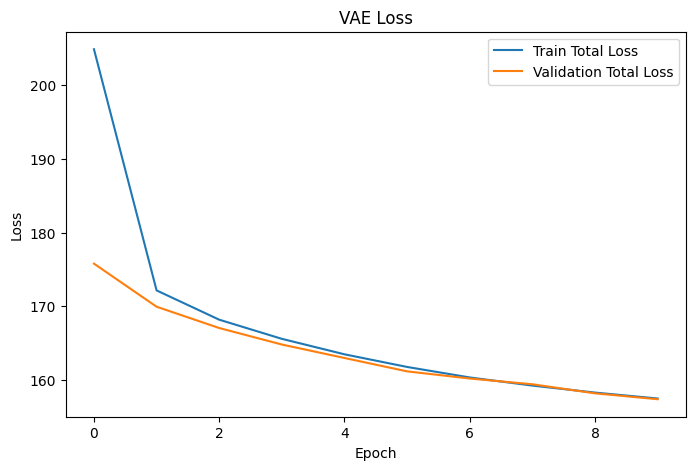

In [27]:
# 6. Train
# --------------------------
history = vae.fit(
    x_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_test, None),
    verbose=1
)

# --------------------------
# 7. Plot training loss
# --------------------------
plt.figure(figsize=(8, 5))
plt.plot(history.history["total_loss"], label="Train Total Loss")
plt.plot(history.history["val_val_total_loss"], label="Validation Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Loss")
plt.legend()
plt.show()


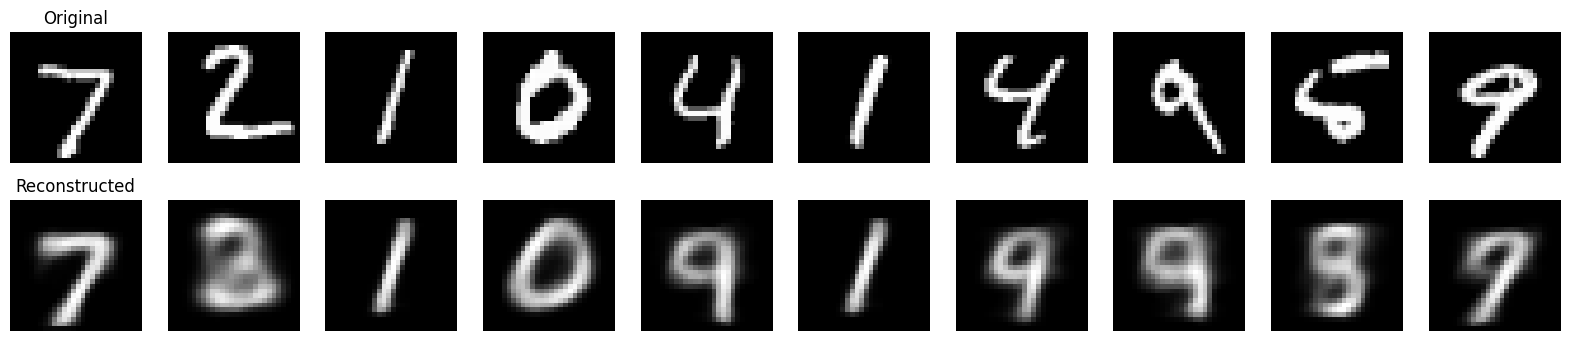

In [28]:
# 8. Reconstruct images
# --------------------------
n = 10
test_images = x_test[:n]
reconstructed = vae.predict(test_images, verbose=0)

plt.figure(figsize=(20, 4))
for i in range(n):
    # original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(test_images[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_title("Original")

    # reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_title("Reconstructed")
plt.show()

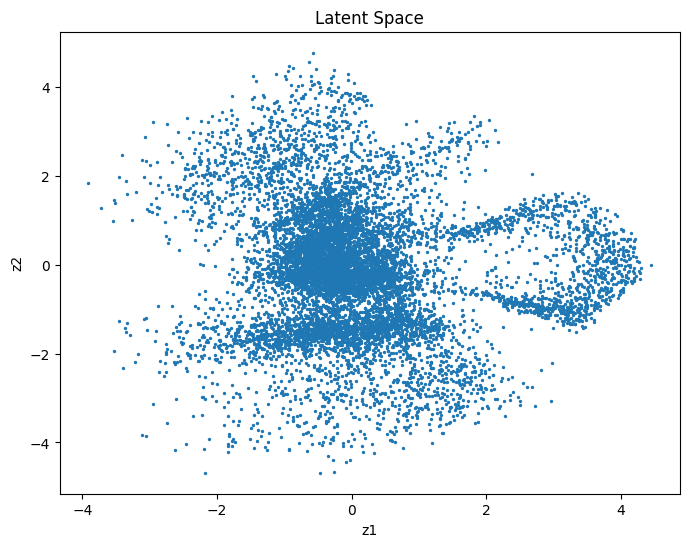

In [29]:
# 9. Plot latent space
# --------------------------
z_mean, _, _ = encoder.predict(x_test, verbose=0)

plt.figure(figsize=(8, 6))
plt.scatter(z_mean[:, 0], z_mean[:, 1], s=2)
plt.xlabel("z1")
plt.ylabel("z2")
plt.title("Latent Space")
plt.show()

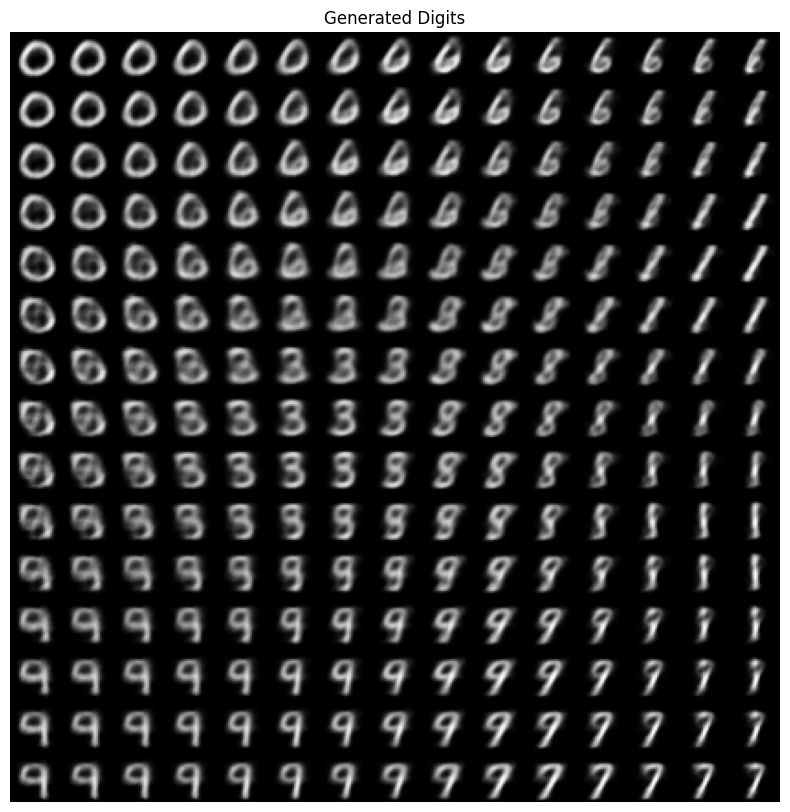

In [30]:
# 10. Generate new digits
# --------------------------
grid_size = 15
digit_size = 28
figure = np.zeros((digit_size * grid_size, digit_size * grid_size))

grid_x = np.linspace(-2, 2, grid_size)
grid_y = np.linspace(-2, 2, grid_size)[::-1]

for i, yi in enumerate(grid_y):
    for j, xi in enumerate(grid_x):
        z_sample = np.array([[xi, yi]], dtype=np.float32)
        decoded = decoder.predict(z_sample, verbose=0)
        digit = decoded[0].reshape(28, 28)
        figure[
            i * digit_size:(i + 1) * digit_size,
            j * digit_size:(j + 1) * digit_size
        ] = digit

plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap="gray")
plt.axis("off")
plt.title("Generated Digits")
plt.show()